In [14]:
using CairoMakie
using HDF5
using Statistics

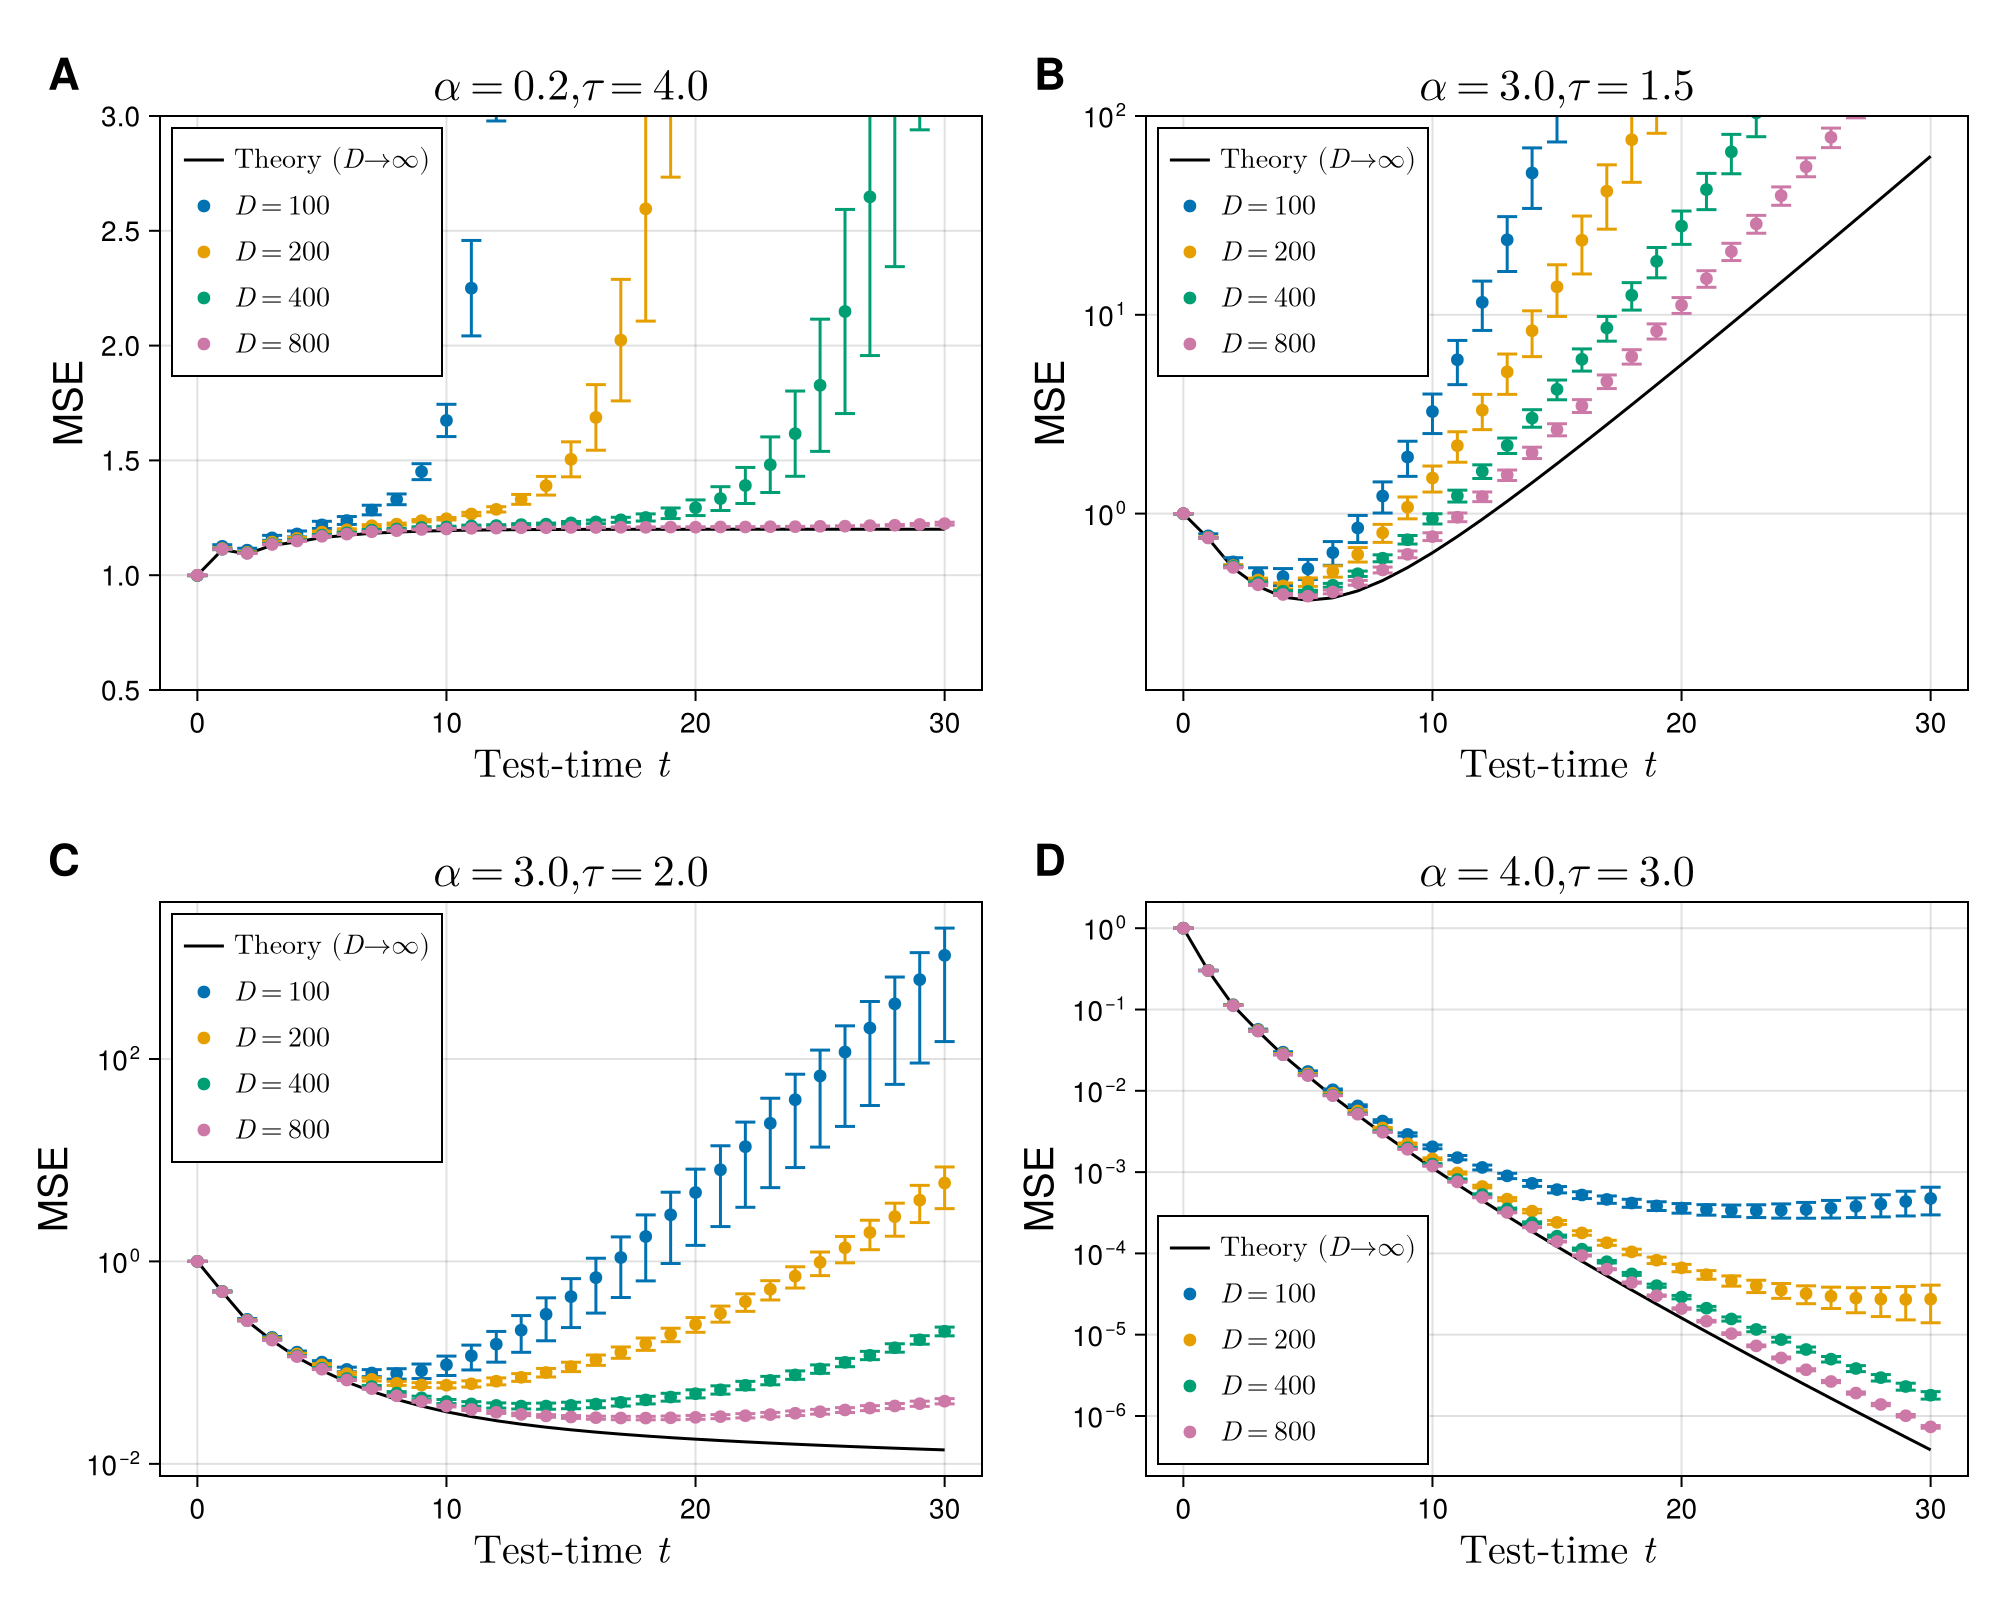

CairoMakie.Screen{PDF}


In [20]:
fig = Figure(size=(1000, 800))

params_list = [(0.2, 4.0), (3.0, 1.5), (3.0, 2.0), (4.0, 3.0)]
limits = [(nothing, nothing, 0.5, 3.0), (nothing, nothing, nothing, 10^2), 
        (nothing, nothing, nothing, nothing), (nothing, nothing, nothing, nothing)]
scalings = [identity, log10, log10, log10]
labels = ["A", "B", "C", "D"]
legend_pos = [:lt, :lt, :lt, :lb]

for (i, params) in enumerate(params_list)
    alpha = params[1]
    tau = params[2]
    path = joinpath(@__DIR__, "simplified_linear_dynamics_theory_experiment_alpha=$(alpha)_tau=$(tau).h5")
    file = h5open(path, "r")
    generalization_error_experiment = read(file, "generalization_error_experiment")
    generalization_error_theory = read(file, "generalization_error_theory")
    Ds = read(file, "Ds")
    tmax = read(file, "tmax")
    experiment_means = mean(generalization_error_experiment, dims=2)
    experiment_ses = std(generalization_error_experiment, dims=2) ./ sqrt(size(generalization_error_experiment, 2))
    close(file)

    pos_x = [1, 1, 2, 2]
    pos_y = [1, 2, 1, 2]

    ax = Axis(
        fig[pos_x[i], pos_y[i]],
        limits=limits[i],
        title=L"\alpha = %$alpha, \tau = %$tau",
        xlabel=L"Test-time $t$",
        ylabel="MSE",
        titlesize=22,
        xlabelsize=20,
        ylabelsize=20,
        yscale=scalings[i],
    )

    lines!(ax, 0:tmax1, vec(generalization_error_theory), label=L"Theory ($D \to \infty$)", color=:black)

    for (j, D) in enumerate(Ds)
        y_mean = vec(experiment_means[j, 1, :])
        y_se = vec(experiment_ses[j, 1, :])
        scatter!(ax, 0:tmax, y_mean, label=L"D = %$D")
        errorbars!(ax, 0:tmax, y_mean, y_se, whiskerwidth=10)
    end

    axislegend(ax, position=legend_pos[i], merge=true)

    Label(fig[pos_x[i], pos_y[i], TopLeft()], labels[i]; 
        font=:bold, fontsize=22, halign=:left, valign=:top, padding=(8, 8, 8, 8))
end


display(fig)
save("theory_vs_experiment.pdf", fig)
